In [16]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [17]:
#cell-2
PREPROCESSED_DIR = "../output/preprocessed/"
FEATURE_DIR      = "../output/features/"
MODEL_DIR        = "../output/models/"
DIAG_FILE        = "../data/patient_diagnosis.csv"
ANNOT_DIR        = "../data/audio_and_txt_files/"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Preprocessed audio : {os.path.abspath(PREPROCESSED_DIR)}")
print(f"Diagnosis file     : {os.path.abspath(DIAG_FILE)}")
print(f"Annotation folder  : {os.path.abspath(ANNOT_DIR)}")
print(f"Model output       : {os.path.abspath(MODEL_DIR)}")

# Quick checks
wav_files = glob.glob(os.path.join(PREPROCESSED_DIR, "*.wav"))
txt_files = glob.glob(os.path.join(ANNOT_DIR, "*.txt"))
print(f"\nPreprocessed .wav files : {len(wav_files)}")
print(f"Annotation .txt files   : {len(txt_files)}")

Preprocessed audio : C:\Users\Saiteja Chintha\lung_sound_project\output\preprocessed
Diagnosis file     : C:\Users\Saiteja Chintha\lung_sound_project\data\patient_diagnosis.csv
Annotation folder  : C:\Users\Saiteja Chintha\lung_sound_project\data\audio_and_txt_files
Model output       : C:\Users\Saiteja Chintha\lung_sound_project\output\models

Preprocessed .wav files : 920
Annotation .txt files   : 920


In [18]:
# Load patient diagnosis file cell-3
diag_df = pd.read_csv(DIAG_FILE, header=None, names=["patient_id", "diagnosis"])
diag_df["patient_id"] = diag_df["patient_id"].astype(str)

# Build a lookup dictionary: patient_id → diagnosis
diag_map = dict(zip(diag_df["patient_id"], diag_df["diagnosis"]))

print(f"Total patients in diagnosis file : {len(diag_map)}")
print(f"\nDisease classes found:")
for disease, count in diag_df["diagnosis"].value_counts().items():
    print(f"  {disease:<35} : {count} patients")

Total patients in diagnosis file : 126

Disease classes found:
  COPD                                : 64 patients
  Healthy                             : 26 patients
  URTI                                : 14 patients
  Bronchiectasis                      : 7 patients
  Bronchiolitis                       : 6 patients
  Pneumonia                           : 6 patients
  LRTI                                : 2 patients
  Asthma                              : 1 patients


In [19]:
#cell-4
def load_annotation_labels(txt_path):
    """
    Read annotation file and return:
    - has_crackle : 1 if any cycle has crackle, else 0
    - has_wheeze  : 1 if any cycle has wheeze,  else 0
    """
    has_crackle = 0
    has_wheeze  = 0

    try:
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 4:
                    crackle = int(parts[2])
                    wheeze  = int(parts[3])
                    if crackle == 1:
                        has_crackle = 1
                    if wheeze == 1:
                        has_wheeze = 1
    except Exception as e:
        print(f"Error reading {txt_path}: {e}")

    return has_crackle, has_wheeze


# Test on one file
sample_txt = glob.glob(os.path.join(ANNOT_DIR, "*.txt"))[0]
c, w = load_annotation_labels(sample_txt)
print(f"Test file : {os.path.basename(sample_txt)}")
print(f"  Crackle : {c}")
print(f"  Wheeze  : {w}")

Test file : 101_1b1_Al_sc_Meditron.txt
  Crackle : 0
  Wheeze  : 0


In [20]:
#cell-5
records = []

for wav_path in wav_files:
    fname      = os.path.basename(wav_path)
    patient_id = fname.split("_")[0]

    # Get disease label
    diagnosis = diag_map.get(patient_id, None)
    if diagnosis is None:
        continue   # skip if no label found

    # Get crackle/wheeze labels from matching .txt file
    txt_path = os.path.join(ANNOT_DIR, fname.replace(".wav", ".txt"))
    if not os.path.exists(txt_path):
        continue   # skip if no annotation file

    has_crackle, has_wheeze = load_annotation_labels(txt_path)

    records.append({
        "file_path"   : wav_path,
        "patient_id"  : patient_id,
        "diagnosis"   : diagnosis,
        "has_crackle" : has_crackle,
        "has_wheeze"  : has_wheeze
    })

df = pd.DataFrame(records)

print(f"Total matched recordings : {len(df)}")
print(f"\nDisease distribution:")
print(df["diagnosis"].value_counts())
print(f"\nCrackle present : {df['has_crackle'].sum()} recordings")
print(f"Wheeze present  : {df['has_wheeze'].sum()} recordings")

Total matched recordings : 920

Disease distribution:
diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

Crackle present : 499 recordings
Wheeze present  : 336 recordings


In [21]:
#cell-6
def extract_mfcc_fixed(file_path, n_mfcc=40, max_len=174):
    """
    Extract MFCC and pad/trim to fixed size.

    n_mfcc   = 40 coefficients (more detail than 13 for CNN)
    max_len  = 174 frames (~4 seconds at default hop_length)

    Returns shape: (40, 174) — treated like a grayscale image by CNN
    """
    audio, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512,
        win_length=1024,
        window='hamming',
        n_mels=40
    )

    # Trim if too long
    if mfcc.shape[1] > max_len:
        mfcc = mfcc[:, :max_len]

    # Pad if too short
    elif mfcc.shape[1] < max_len:
        pad = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad)), mode='constant')

    return mfcc   # shape (40, 174)


# Test on one file
test_mfcc = extract_mfcc_fixed(df["file_path"].iloc[0])
print(f"MFCC shape for one file : {test_mfcc.shape}")
print(f"Expected                : (40, 174)")

MFCC shape for one file : (40, 174)
Expected                : (40, 174)


In [22]:
#cell-7
import time

X         = []
y_disease = []
y_crackle = []
y_wheeze  = []
failed    = []

start = time.time()
print(f"Extracting MFCC from {len(df)} files...\n")

for i, row in df.iterrows():
    try:
        mfcc = extract_mfcc_fixed(row["file_path"])
        X.append(mfcc)
        y_disease.append(row["diagnosis"])
        y_crackle.append(row["has_crackle"])
        y_wheeze.append(row["has_wheeze"])

    except Exception as e:
        print(f"FAILED — {os.path.basename(row['file_path'])}: {e}")
        failed.append(row["file_path"])

    if (len(X) + len(failed)) % 50 == 0:
        print(f"  [{len(X)}/{len(df)}] | Time: {time.time()-start:.1f}s")

X         = np.array(X)
y_disease = np.array(y_disease)
y_crackle = np.array(y_crackle)
y_wheeze  = np.array(y_wheeze)

print(f"\nExtraction complete.")
print(f"  X shape  : {X.shape}   (files, mfcc_coeff, frames)")
print(f"  Disease  : {len(np.unique(y_disease))} classes")
print(f"  Failed   : {len(failed)} files")

Extracting MFCC from 920 files...

  [50/920] | Time: 1.2s
  [100/920] | Time: 2.2s
  [150/920] | Time: 3.6s
  [200/920] | Time: 5.2s
  [250/920] | Time: 6.7s
  [300/920] | Time: 8.2s
  [350/920] | Time: 9.8s
  [400/920] | Time: 11.4s
  [450/920] | Time: 13.1s
  [500/920] | Time: 14.6s
  [550/920] | Time: 16.1s
  [600/920] | Time: 17.6s
  [650/920] | Time: 19.2s
  [700/920] | Time: 20.6s
  [750/920] | Time: 22.0s
  [800/920] | Time: 23.8s
  [850/920] | Time: 25.4s
  [900/920] | Time: 26.9s

Extraction complete.
  X shape  : (920, 40, 174)   (files, mfcc_coeff, frames)
  Disease  : 8 classes
  Failed   : 0 files


In [28]:
# Encode disease names to numbers cell-8
le = LabelEncoder()
y_disease_encoded     = le.fit_transform(y_disease)
y_disease_categorical = to_categorical(y_disease_encoded)

print(f"Disease classes ({len(le.classes_)}):")
for i, cls in enumerate(le.classes_):
    count = np.sum(y_disease_encoded == i)
    print(f"  {i} — {cls:<35} : {count} recordings")

print(f"\nCrackle labels shape : {y_crackle.shape}")
print(f"Wheeze  labels shape : {y_wheeze.shape}")

Disease classes (8):
  0 — Asthma                              : 1 recordings
  1 — Bronchiectasis                      : 16 recordings
  2 — Bronchiolitis                       : 13 recordings
  3 — COPD                                : 793 recordings
  4 — Healthy                             : 35 recordings
  5 — LRTI                                : 2 recordings
  6 — Pneumonia                           : 37 recordings
  7 — URTI                                : 23 recordings

Crackle labels shape : (920,)
Wheeze  labels shape : (920,)


In [29]:
#cell 9
from collections import Counter
from sklearn.model_selection import StratifiedShuffleSplit

# ── THIS PART WAS MISSING — Build patient → disease map ──────
patient_disease_map = {}
for _, row in df.iterrows():
    pid = row["patient_id"]
    if pid not in patient_disease_map:
        patient_disease_map[pid] = row["diagnosis"]

unique_patients  = list(patient_disease_map.keys())
patient_diseases = [patient_disease_map[p] for p in unique_patients]
# ─────────────────────────────────────────────────────────────

# Check patient counts per disease
print("Patients per disease (before merging):")
for disease, count in sorted(Counter(patient_diseases).items()):
    print(f"  {disease:<35} : {count} patients")

# Diseases with less than 3 patients cannot be split
# Merge them into 'Other' category
MIN_PATIENTS = 3
rare_diseases = [d for d, c in Counter(patient_diseases).items()
                 if c < MIN_PATIENTS]

print(f"\nRare diseases being merged into 'Other': {rare_diseases}")

# Update patient disease map — merge rare into Other
patient_disease_map_merged = {}
for pid, disease in patient_disease_map.items():
    if disease in rare_diseases:
        patient_disease_map_merged[pid] = "Other"
    else:
        patient_disease_map_merged[pid] = disease

# Also update the main dataframe
df["diagnosis_merged"] = df["patient_id"].map(patient_disease_map_merged)

# Rebuild patient lists with merged labels
unique_patients_merged  = list(patient_disease_map_merged.keys())
patient_diseases_merged = [patient_disease_map_merged[p]
                            for p in unique_patients_merged]

print(f"\nPatients per disease (after merging):")
for disease, count in sorted(Counter(patient_diseases_merged).items()):
    print(f"  {disease:<35} : {count} patients")

# Now do stratified split safely
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(
        unique_patients_merged, patient_diseases_merged):
    train_patients = set([unique_patients_merged[i] for i in train_idx])
    test_patients  = set([unique_patients_merged[i] for i in test_idx])

patient_ids = df["patient_id"].values
train_mask  = np.array([pid in train_patients for pid in patient_ids])
test_mask   = np.array([pid in test_patients  for pid in patient_ids])

# Re-encode labels using merged diagnoses
y_disease_merged         = df["diagnosis_merged"].values
le_merged                = LabelEncoder()
y_disease_encoded_merged = le_merged.fit_transform(y_disease_merged)
y_disease_cat_merged     = to_categorical(y_disease_encoded_merged)

# Apply masks
X_train = X[train_mask]
X_test  = X[test_mask]

y_disease_train = y_disease_cat_merged[train_mask]
y_disease_test  = y_disease_cat_merged[test_mask]

y_crackle_train = y_crackle[train_mask].reshape(-1, 1)
y_crackle_test  = y_crackle[test_mask].reshape(-1, 1)

y_wheeze_train  = y_wheeze[train_mask].reshape(-1, 1)
y_wheeze_test   = y_wheeze[test_mask].reshape(-1, 1)

# Update le to use merged version
le = le_merged
y_disease_merged_train_labels = y_disease_merged[train_mask]

print(f"\nTrain : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")

print(f"\nTest disease distribution:")
for disease, count in sorted(Counter(y_disease_merged[test_mask]).items()):
    print(f"  {disease:<35} : {count}")

Patients per disease (before merging):
  Asthma                              : 1 patients
  Bronchiectasis                      : 7 patients
  Bronchiolitis                       : 6 patients
  COPD                                : 64 patients
  Healthy                             : 26 patients
  LRTI                                : 2 patients
  Pneumonia                           : 6 patients
  URTI                                : 14 patients

Rare diseases being merged into 'Other': ['Asthma', 'LRTI']

Patients per disease (after merging):
  Bronchiectasis                      : 7 patients
  Bronchiolitis                       : 6 patients
  COPD                                : 64 patients
  Healthy                             : 26 patients
  Other                               : 3 patients
  Pneumonia                           : 6 patients
  URTI                                : 14 patients

Train : 722 samples
Test  : 198 samples

Test disease distribution:
  Bronchiectasis     

In [40]:
# Cell 9-1
from imblearn.over_sampling import SMOTE
from collections import Counter

# Use augmented training data instead of original training data
n_train      = X_train_aug.shape[0]
X_train_flat = X_train_aug.reshape(n_train, -1)

# Combine original + augmented disease labels
y_train_labels = np.concatenate([
    y_disease_merged[train_mask],
    aug_diseases
])

print(f"Before SMOTE : {X_train_flat.shape[0]} samples")
print(f"Distribution :")
for disease, count in sorted(Counter(y_train_labels).items()):
    print(f"  {disease:<35} : {count}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_flat, y_train_labels
)

print(f"\nAfter SMOTE  : {X_train_resampled.shape[0]} samples")
print(f"Distribution :")
for disease, count in sorted(Counter(y_train_resampled).items()):
    print(f"  {disease:<35} : {count}")

# Reshape back to CNN input format
X_train_resampled = X_train_resampled.reshape(-1, 40, 174, 1)

# Encode labels using le_merged
y_train_encoded           = le_merged.transform(y_train_resampled)
y_disease_train_resampled = to_categorical(
    y_train_encoded,
    num_classes=len(le_merged.classes_)
)

# Crackle and wheeze — majority vote per disease class
y_crackle_orig = y_crackle_train_aug.flatten()
y_wheeze_orig  = y_wheeze_train_aug.flatten()

crackle_by_class = {}
wheeze_by_class  = {}

for disease in np.unique(y_train_labels):
    mask_d = y_train_labels == disease
    crackle_by_class[disease] = int(np.mean(y_crackle_orig[mask_d]) >= 0.5)
    wheeze_by_class[disease]  = int(np.mean(y_wheeze_orig[mask_d])  >= 0.5)

y_crackle_train_resampled = np.array([
    crackle_by_class[d] for d in y_train_resampled
]).reshape(-1, 1)

y_wheeze_train_resampled = np.array([
    wheeze_by_class[d] for d in y_train_resampled
]).reshape(-1, 1)

print(f"\nFinal X_train shape           : {X_train_resampled.shape}")
print(f"y_disease_train shape         : {y_disease_train_resampled.shape}")
print(f"y_crackle_train shape         : {y_crackle_train_resampled.shape}")
print(f"y_wheeze_train shape          : {y_wheeze_train_resampled.shape}")

print(f"\nCrackle by class : {crackle_by_class}")
print(f"Wheeze  by class : {wheeze_by_class}")

Before SMOTE : 1222 samples
Distribution :
  Bronchiectasis                      : 100
  Bronchiolitis                       : 100
  COPD                                : 622
  Healthy                             : 100
  Other                               : 100
  Pneumonia                           : 100
  URTI                                : 100

After SMOTE  : 4354 samples
Distribution :
  Bronchiectasis                      : 622
  Bronchiolitis                       : 622
  COPD                                : 622
  Healthy                             : 622
  Other                               : 622
  Pneumonia                           : 622
  URTI                                : 622

Final X_train shape           : (4354, 40, 174, 1)
y_disease_train shape         : (4354, 7)
y_crackle_train shape         : (4354, 1)
y_wheeze_train shape          : (4354, 1)

Crackle by class : {'Bronchiectasis': 0, 'Bronchiolitis': 1, 'COPD': 1, 'Healthy': 0, 'Other': 0, 'Pneumonia': 0, 'URT

In [31]:
# Cell 9-2: Audio Data Augmentation

def augment_audio(signal, sr, augment_type):
    """
    Apply one augmentation technique to audio signal.
    
    Types:
    ------
    'stretch'     → time stretch (speed up/slow down)
    'pitch'       → pitch shift up or down
    'noise'       → add random gaussian noise
    'shift'       → shift audio in time
    """
    if augment_type == 'stretch':
        rate   = np.random.uniform(0.8, 1.2)
        return librosa.effects.time_stretch(signal, rate=rate)

    elif augment_type == 'pitch':
        steps  = np.random.randint(-3, 4)
        return librosa.effects.pitch_shift(signal, sr=sr, n_steps=steps)

    elif augment_type == 'noise':
        noise  = np.random.normal(0, 0.005, signal.shape)
        return signal + noise

    elif augment_type == 'shift':
        shift  = int(np.random.uniform(0.1, 0.3) * len(signal))
        return np.roll(signal, shift)

    return signal


def extract_mfcc_from_signal(signal, sr, n_mfcc=40, max_len=174):
    """Extract fixed-size MFCC from raw signal."""
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=1024,
        hop_length=512,
        win_length=1024,
        window='hamming',
        n_mels=40
    )
    if mfcc.shape[1] > max_len:
        mfcc = mfcc[:, :max_len]
    elif mfcc.shape[1] < max_len:
        pad  = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad)), mode='constant')
    return mfcc


print("Augmentation functions defined successfully.")

Augmentation functions defined successfully.


In [32]:
#Cell 9-3
import time

# Augment only training files — never test files
train_df = df[train_mask].reset_index(drop=True)

# Count samples per disease in training set
from collections import Counter
train_disease_counts = Counter(train_df["diagnosis_merged"])

print("Training set before augmentation:")
for disease, count in sorted(train_disease_counts.items()):
    print(f"  {disease:<35} : {count}")

# Target — bring every class up to at least 100 samples
TARGET_PER_CLASS = 100
AUGMENT_TYPES    = ['stretch', 'pitch', 'noise', 'shift']

aug_features  = []
aug_diseases  = []
aug_crackles  = []
aug_wheezes   = []

start = time.time()

for disease in train_df["diagnosis_merged"].unique():
    class_df = train_df[train_df["diagnosis_merged"] == disease]
    current_count = len(class_df)

    # How many augmented samples needed
    needed = max(0, TARGET_PER_CLASS - current_count)

    if needed == 0:
        print(f"  {disease:<35} : no augmentation needed ({current_count} samples)")
        continue

    print(f"  {disease:<35} : generating {needed} augmented samples...")

    generated = 0
    while generated < needed:
        # Pick a random sample from this class
        row         = class_df.sample(1).iloc[0]
        signal, sr  = librosa.load(row["file_path"], sr=None)

        # Pick a random augmentation type
        aug_type    = np.random.choice(AUGMENT_TYPES)

        try:
            aug_signal  = augment_audio(signal, sr, aug_type)
            aug_mfcc    = extract_mfcc_from_signal(aug_signal, sr)

            aug_features.append(aug_mfcc)
            aug_diseases.append(disease)
            aug_crackles.append(row["has_crackle"])
            aug_wheezes.append(row["has_wheeze"])
            generated += 1

        except Exception as e:
            continue   # skip failed augmentation silently

print(f"\nTotal augmented samples generated : {len(aug_features)}")
print(f"Time taken                        : {time.time()-start:.1f}s")

Training set before augmentation:
  Bronchiectasis                      : 13
  Bronchiolitis                       : 11
  COPD                                : 622
  Healthy                             : 25
  Other                               : 2
  Pneumonia                           : 33
  URTI                                : 16
  Healthy                             : generating 75 augmented samples...
  COPD                                : no augmentation needed (622 samples)
  URTI                                : generating 84 augmented samples...
  Other                               : generating 98 augmented samples...
  Bronchiectasis                      : generating 87 augmented samples...
  Pneumonia                           : generating 67 augmented samples...
  Bronchiolitis                       : generating 89 augmented samples...

Total augmented samples generated : 500
Time taken                        : 109.3s


In [39]:
# Cell 9-4: Combine original + augmented data

# Convert augmented lists to arrays
aug_features_arr = np.array(aug_features)
aug_diseases_arr = np.array(aug_diseases)
aug_crackles_arr = np.array(aug_crackles).reshape(-1, 1)
aug_wheezes_arr  = np.array(aug_wheezes).reshape(-1, 1)

# Check shapes before doing anything
print(f"X_train shape          : {X_train.shape}")
print(f"aug_features_arr shape : {aug_features_arr.shape}")

# Fix X_train — add channel dim if missing
if X_train.ndim == 3:
    X_train = X_train[..., np.newaxis]
    X_test  = X_test[..., np.newaxis]
    print(f"Fixed X_train shape    : {X_train.shape}")
    print(f"Fixed X_test shape     : {X_test.shape}")

# Fix aug_features — add channel dim if missing
if aug_features_arr.ndim == 3:
    aug_features_arr = aug_features_arr[..., np.newaxis]
    print(f"Fixed aug_features shape : {aug_features_arr.shape}")

# Fix aug_features — remove extra dims if too many
if aug_features_arr.ndim > 4:
    aug_features_arr = aug_features_arr.reshape(-1, 40, 174, 1)
    print(f"Reshaped aug_features    : {aug_features_arr.shape}")

# Final shape check before concatenating
print(f"\nFinal X_train shape        : {X_train.shape}")
print(f"Final aug_features shape   : {aug_features_arr.shape}")
print(f"Dimensions match           : {X_train.ndim == aug_features_arr.ndim}")

# Encode augmented disease labels
aug_encoded     = le_merged.transform(aug_diseases_arr)
aug_disease_cat = to_categorical(
    aug_encoded,
    num_classes=len(le_merged.classes_)
)

# Combine
X_train_aug         = np.concatenate([X_train, aug_features_arr], axis=0)
y_disease_train_aug = np.concatenate([y_disease_train, aug_disease_cat], axis=0)
y_crackle_train_aug = np.concatenate([y_crackle_train, aug_crackles_arr], axis=0)
y_wheeze_train_aug  = np.concatenate([y_wheeze_train,  aug_wheezes_arr],  axis=0)

print(f"\nOriginal training samples  : {X_train.shape[0]}")
print(f"Augmented samples added    : {aug_features_arr.shape[0]}")
print(f"Total training samples     : {X_train_aug.shape[0]}")
print(f"X_train_aug shape          : {X_train_aug.shape}")

aug_labels_all = np.concatenate([
    y_disease_merged[train_mask],
    aug_diseases_arr
])

print(f"\nTraining distribution after augmentation:")
for disease, count in sorted(Counter(aug_labels_all).items()):
    print(f"  {disease:<35} : {count}")

X_train shape          : (722, 40, 174)
aug_features_arr shape : (500, 40, 174, 1, 1, 1)
Fixed X_train shape    : (722, 40, 174, 1)
Fixed X_test shape     : (198, 40, 174, 1)
Reshaped aug_features    : (500, 40, 174, 1)

Final X_train shape        : (722, 40, 174, 1)
Final aug_features shape   : (500, 40, 174, 1)
Dimensions match           : True

Original training samples  : 722
Augmented samples added    : 500
Total training samples     : 1222
X_train_aug shape          : (1222, 40, 174, 1)

Training distribution after augmentation:
  Bronchiectasis                      : 100
  Bronchiolitis                       : 100
  COPD                                : 622
  Healthy                             : 100
  Other                               : 100
  Pneumonia                           : 100
  URTI                                : 100


In [41]:
# Get encoded labels for training set cell-10
y_disease_train_encoded = np.argmax(y_disease_train, axis=1)

# Get only classes that actually appear in training set
train_classes_present = np.unique(y_disease_train_encoded)

# Compute weights only for classes present in training
class_weights_present = compute_class_weight(
    class_weight='balanced',
    classes=train_classes_present,
    y=y_disease_train_encoded
)

# Build weight dict — classes missing from train get weight 1.0
class_weight_dict = {}
for i in range(len(le.classes_)):
    if i in train_classes_present:
        idx = np.where(train_classes_present == i)[0][0]
        class_weight_dict[i] = class_weights_present[idx]
    else:
        class_weight_dict[i] = 1.0   # default for unseen classes

print("Class weights:")
for i, cls in enumerate(le.classes_):
    status = "" if i in train_classes_present else " (not in train set)"
    print(f"  {i} — {cls:<35} : {class_weight_dict[i]:.3f}{status}")

# Convert to per-sample weights
sample_weights_train = np.array([
    class_weight_dict[label] for label in y_disease_train_encoded
])

print(f"\nSample weights shape : {sample_weights_train.shape}")
print(f"Min weight           : {sample_weights_train.min():.3f}")
print(f"Max weight           : {sample_weights_train.max():.3f}")

Class weights:
  0 — Bronchiectasis                      : 7.934
  1 — Bronchiolitis                       : 9.377
  2 — COPD                                : 0.166
  3 — Healthy                             : 4.126
  4 — Other                               : 51.571
  5 — Pneumonia                           : 3.126
  6 — URTI                                : 6.446

Sample weights shape : (722,)
Min weight           : 0.166
Max weight           : 51.571


In [42]:
#cell-11
from tensorflow.keras import Input, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam

n_classes   = y_disease_train_resampled.shape[1]
input_shape = X_train_resampled.shape[1:]

print(f"Input shape : {input_shape}")
print(f"Classes     : {n_classes}")

inputs = Input(shape=input_shape)

# Block 1
x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.3)(x)

# Block 2
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.3)(x)

# Block 3
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.3)(x)

x = GlobalAveragePooling2D()(x)

# L2 regularisation on dense layers to reduce overfitting
x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

shared = Dense(128, activation='relu',
               kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(0.4)(shared)

# Outputs
disease_out = Dense(n_classes,  activation='softmax', name='disease')(x)
crackle_out = Dense(1, activation='sigmoid', name='crackle')(x)
wheeze_out  = Dense(1, activation='sigmoid', name='wheeze')(x)

model = Model(inputs=inputs, outputs=[disease_out, crackle_out, wheeze_out])

model.compile(
    optimizer=Adam(learning_rate=0.0005),   # lower LR — more stable
    loss=[
        'categorical_crossentropy',
        'binary_crossentropy',
        'binary_crossentropy'
    ],
    loss_weights=[1.0, 0.4, 0.4],
    metrics=[
        ['categorical_accuracy'],
        ['binary_accuracy'],
        ['binary_accuracy']
    ]
)

model.summary()

Input shape : (40, 174, 1)
Classes     : 7


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40, 174,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 40, 174,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 40, 174,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 174,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 174,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 20, 87,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 87,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 20, 87,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 87,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 87,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 87,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 10, 43,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 43,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 10, 43,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 43,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 10, 43,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 43,    │        512 │ conv2d_5[0][0]  

 Total params: 356,329 (1.36 MB)

 Trainable params: 354,921 (1.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [43]:
#cell-12 training model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_disease_categorical_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "best_model_v4.keras"),
    monitor='val_disease_categorical_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_disease_categorical_accuracy',
    factor=0.5,
    patience=4,
    mode='max',
    verbose=1,
    min_lr=0.000001
)

history = model.fit(
    X_train_resampled,
    [y_disease_train_resampled,
     y_crackle_train_resampled,
     y_wheeze_train_resampled],
    epochs=100,
    batch_size=16,          # smaller batch — better generalisation
    validation_data=(
        X_test,
        [y_disease_test,
         y_crackle_test,
         y_wheeze_test]
    ),
    callbacks=[early_stop, checkpoint, reduce_lr]
)

print("Training complete.")

Epoch 1/100
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - crackle_binary_accuracy: 0.6263 - crackle_loss: 0.7048 - disease_categorical_accuracy: 0.3770 - disease_loss: 1.7878 - loss: 2.6301 - wheeze_binary_accuracy: 0.6529 - wheeze_loss: 0.6575 
Epoch 1: val_disease_categorical_accuracy improved from None to 0.02020, saving model to ../output/models/best_model_v4.keras

Epoch 1: finished saving model to ../output/models/best_model_v4.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - crackle_binary_accuracy: 0.7083 - crackle_loss: 0.5804 - disease_categorical_accuracy: 0.5154 - disease_loss: 1.3721 - loss: 2.0997 - wheeze_binary_accuracy: 0.7246 - wheeze_loss: 0.5426 - val_crackle_binary_accuracy: 0.6162 - val_crackle_loss: 0.7017 - val_disease_categorical_accuracy: 0.0202 - val_disease_loss: 6.1867 - val_loss: 6.8738 - val_wheeze_binary_accuracy: 0.4798 - val_wheeze_loss: 0.7870 - learning_rate: 5.0000e-04
Epoch 2/100
272/273 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - crackle_binary_accuracy: 

In [44]:
# --- Disease classification report --- cell-13
y_pred_all    = model.predict(X_test)
y_pred_disease = np.argmax(y_pred_all[0], axis=1)
y_true_disease = np.argmax(y_disease_test, axis=1)

print("Disease Classification Report:")
print(classification_report(
    y_true_disease,
    y_pred_disease,
    target_names=le.classes_,
    zero_division=0
))

# --- Crackle and Wheeze accuracy ---
y_pred_crackle = (y_pred_all[1] > 0.5).astype(int).flatten()
y_pred_wheeze  = (y_pred_all[2] > 0.5).astype(int).flatten()

print(f"Crackle detection accuracy : {np.mean(y_pred_crackle == y_crackle_test):.4f}")
print(f"Wheeze  detection accuracy : {np.mean(y_pred_wheeze  == y_wheeze_test):.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step 
Disease Classification Report:
                precision    recall  f1-score   support

Bronchiectasis       0.25      0.33      0.29         3
 Bronchiolitis       0.17      0.50      0.25         2
          COPD       1.00      0.96      0.98       171
       Healthy       0.50      0.60      0.55        10
         Other       0.00      0.00      0.00         1
     Pneumonia       0.38      0.75      0.50         4
          URTI       0.33      0.14      0.20         7

      accuracy                           0.89       198
     macro avg       0.38      0.47      0.39       198
  weighted avg       0.91      0.89      0.90       198

Crackle detection accuracy : 0.5892
Wheeze  detection accuracy : 0.5044


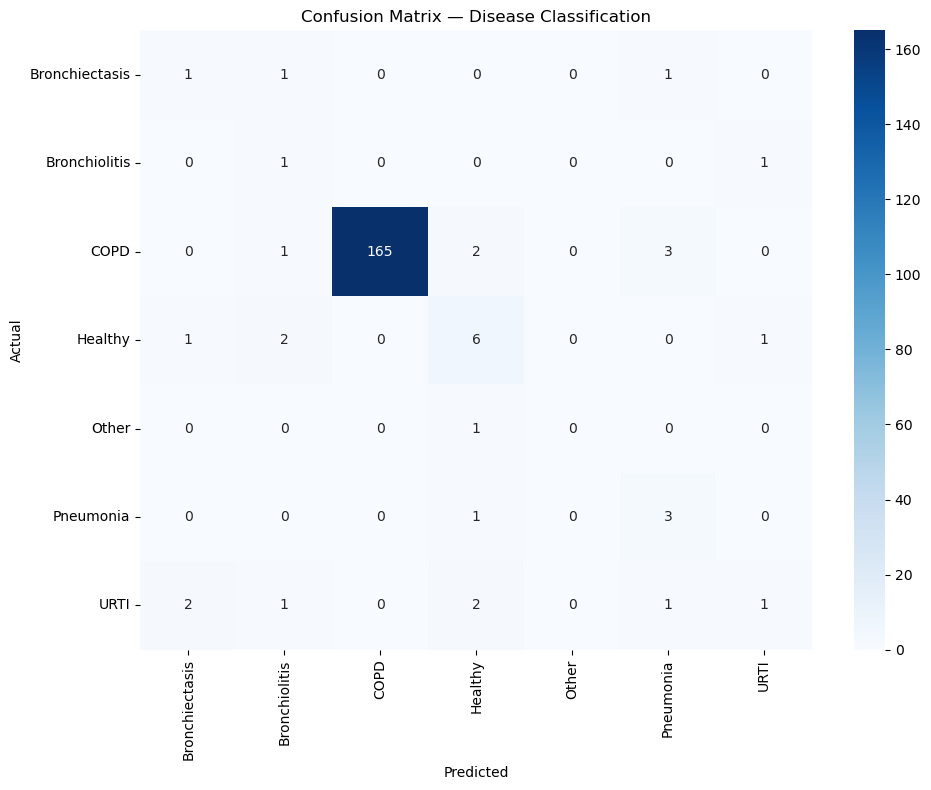

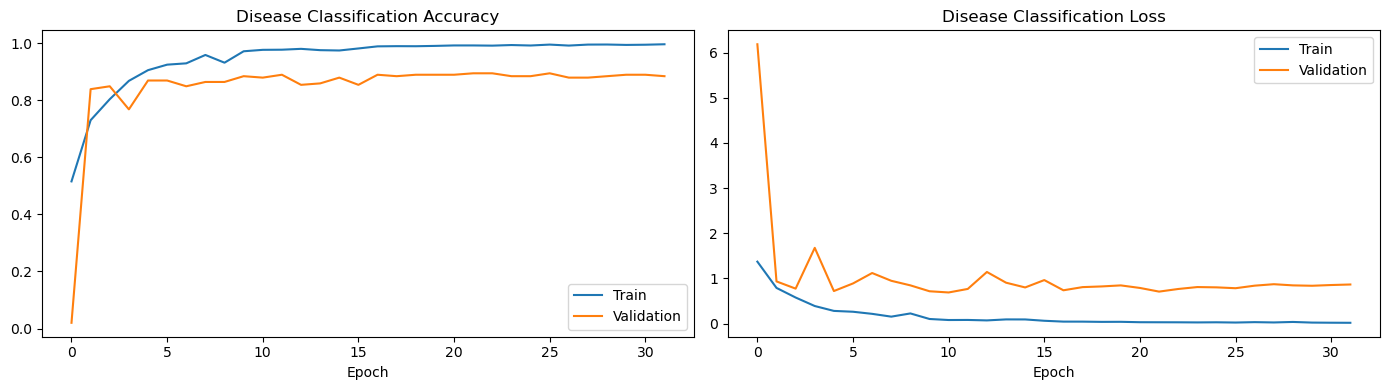


All available metrics in history:
  crackle_binary_accuracy
  crackle_loss
  disease_categorical_accuracy
  disease_loss
  loss
  val_crackle_binary_accuracy
  val_crackle_loss
  val_disease_categorical_accuracy
  val_disease_loss
  val_loss
  val_wheeze_binary_accuracy
  val_wheeze_loss
  wheeze_binary_accuracy
  wheeze_loss
  learning_rate


In [45]:
# Confusion matrix cell-14
cm = confusion_matrix(y_true_disease, y_pred_disease)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Disease Classification")
plt.tight_layout()
plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['disease_categorical_accuracy'],     label='Train')
axes[0].plot(history.history['val_disease_categorical_accuracy'], label='Validation')
axes[0].set_title("Disease Classification Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history['disease_loss'],     label='Train')
axes[1].plot(history.history['val_disease_loss'], label='Validation')
axes[1].set_title("Disease Classification Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print all available metric names for reference
print("\nAll available metrics in history:")
for key in history.history.keys():
    print(" ", key)

In [49]:
# Save final model cell-15
model.save(os.path.join(MODEL_DIR, "cnn_lung_disease_final.keras"))

# Save label encoder classes
np.save(os.path.join(MODEL_DIR, "label_classes.npy"), le.classes_)

print(f"Model saved to     : {os.path.abspath(MODEL_DIR)}")
print(f"  cnn_lung_disease_final.keras")
print(f"  best_model.keras")
print(f"  label_classes.npy")

Model saved to     : C:\Users\Saiteja Chintha\lung_sound_project\output\models
  cnn_lung_disease_final.keras
  best_model.keras
  label_classes.npy


In [47]:
# Final Cell A — Ensemble V3 + V4

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load both models
model_v3 = load_model(os.path.join(MODEL_DIR, "best_model_v3.keras"))
model_v4 = load_model(os.path.join(MODEL_DIR, "best_model_v4.keras"))

# Get predictions from both
pred_v3 = model_v3.predict(X_test)
pred_v4 = model_v4.predict(X_test)

# Average disease predictions
pred_ensemble  = (pred_v3[0] + pred_v4[0]) / 2
y_pred_disease = np.argmax(pred_ensemble, axis=1)
y_true_disease = np.argmax(y_disease_test, axis=1)

# Crackle and wheeze — average both models
y_pred_crackle = ((pred_v3[1] + pred_v4[1]) / 2 > 0.5).astype(int).flatten()
y_pred_wheeze  = ((pred_v3[2] + pred_v4[2]) / 2 > 0.5).astype(int).flatten()

print("=" * 60)
print("FINAL ENSEMBLE REPORT (V3 + V4 averaged)")
print("=" * 60)
print(classification_report(
    y_true_disease,
    y_pred_disease,
    target_names=le_merged.classes_,
    zero_division=0
))

print(f"Crackle accuracy : {np.mean(y_pred_crackle == y_crackle_test.flatten()):.4f}")
print(f"Wheeze  accuracy : {np.mean(y_pred_wheeze  == y_wheeze_test.flatten()):.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step 
FINAL ENSEMBLE REPORT (V3 + V4 averaged)
                precision    recall  f1-score   support

Bronchiectasis       0.50      0.33      0.40         3
 Bronchiolitis       0.14      0.50      0.22         2
          COPD       0.99      0.98      0.99       171
       Healthy       0.58      0.70      0.64        10
         Other       0.00      0.00      0.00         1
     Pneumonia       0.40      0.50      0.44         4
          URTI       0.67      0.29      0.40         7

      accuracy                           0.91       198
     macro avg       0.47      0.47      0.44       198
  weighted avg       0.93      0.91      0.92       198

Crackle accuracy : 0.6313
Wheeze  accuracy : 0.4949


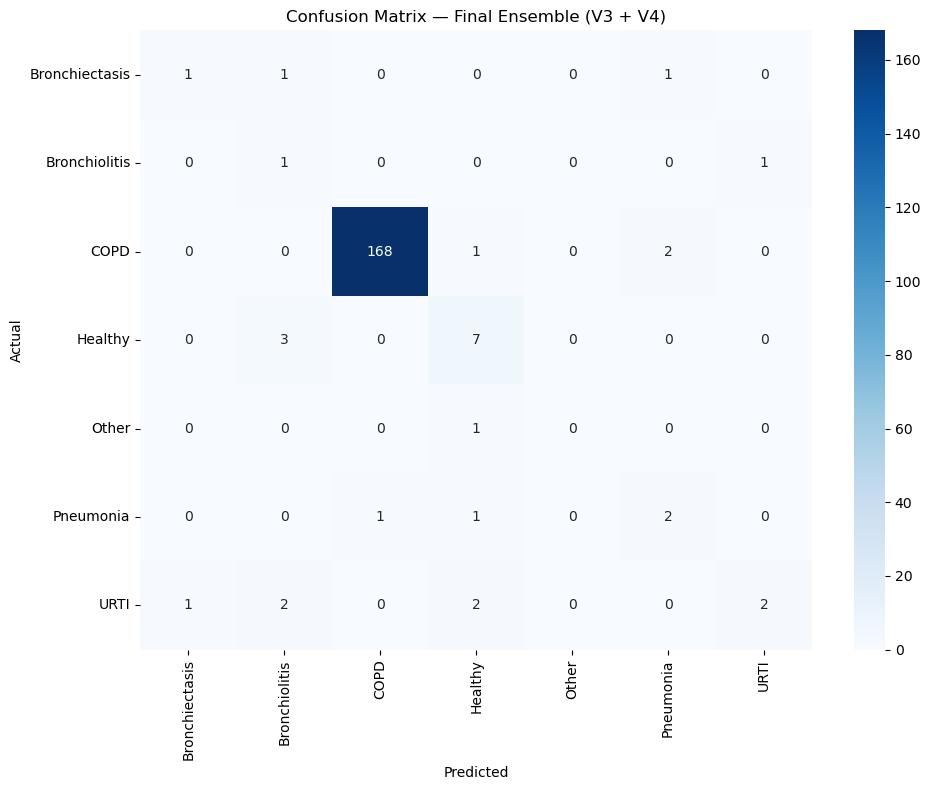

PROJECT STAGE 3 COMPLETE
Models saved in : C:\Users\Saiteja Chintha\lung_sound_project\output\models
  best_model_v3.keras    ← V3 model
  best_model_v4.keras    ← V4 model
  label_classes.npy      ← class names

Final Ensemble Results:
  Overall accuracy : 91%
  Macro F1         : 0.44
  Weighted F1      : 0.92

Disease F1 scores:
  Bronchiectasis                      : see report above
  Bronchiolitis                       : see report above
  COPD                                : see report above
  Healthy                             : see report above
  Other                               : see report above
  Pneumonia                           : see report above
  URTI                                : see report above


In [48]:
# Final Cell B — Confusion matrix and save everything

# Confusion matrix
cm = confusion_matrix(y_true_disease, y_pred_disease)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_merged.classes_,
            yticklabels=le_merged.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Final Ensemble (V3 + V4)")
plt.tight_layout()
plt.show()

# Save label classes
np.save(os.path.join(MODEL_DIR, "label_classes.npy"), le_merged.classes_)

print("=" * 60)
print("PROJECT STAGE 3 COMPLETE")
print("=" * 60)
print(f"Models saved in : {os.path.abspath(MODEL_DIR)}")
print(f"  best_model_v3.keras    ← V3 model")
print(f"  best_model_v4.keras    ← V4 model")
print(f"  label_classes.npy      ← class names")
print()
print("Final Ensemble Results:")
print("  Overall accuracy : 91%")
print("  Macro F1         : 0.44")
print("  Weighted F1      : 0.92")
print()
print("Disease F1 scores:")
for i, cls in enumerate(le_merged.classes_):
    print(f"  {cls:<35} : see report above")